# Posterior Overlay and Importance Sampling (Clean)

这个 notebook 做三件事：
1. 读取 joint strong-lensing posterior、PDSPL h5 和 Fundamental Plane CSV。
2. 用 PDSPL 和 Fundamental Plane 在 `(Omegam, w0, wa)` 上对 joint strong-lensing posterior 做 importance reweight。
3. 把 `dspl_clean.nc / lens_kin_clean.nc / quasar_clean.nc / sne_clean.nc / PDSPL(h5) / Fundamental Plane(csv)` 后验画在同一张 corner 图上。



w0-wa FoM
Before importance sampling: 20.6517
After PDSPL importance sampling: 21.5234 (ratio=1.042)
After Fundamental Plane importance sampling: 32.0700 (ratio=1.553)
After PDSPL + Fundamental Plane importance sampling: 32.4942 (ratio=1.573)


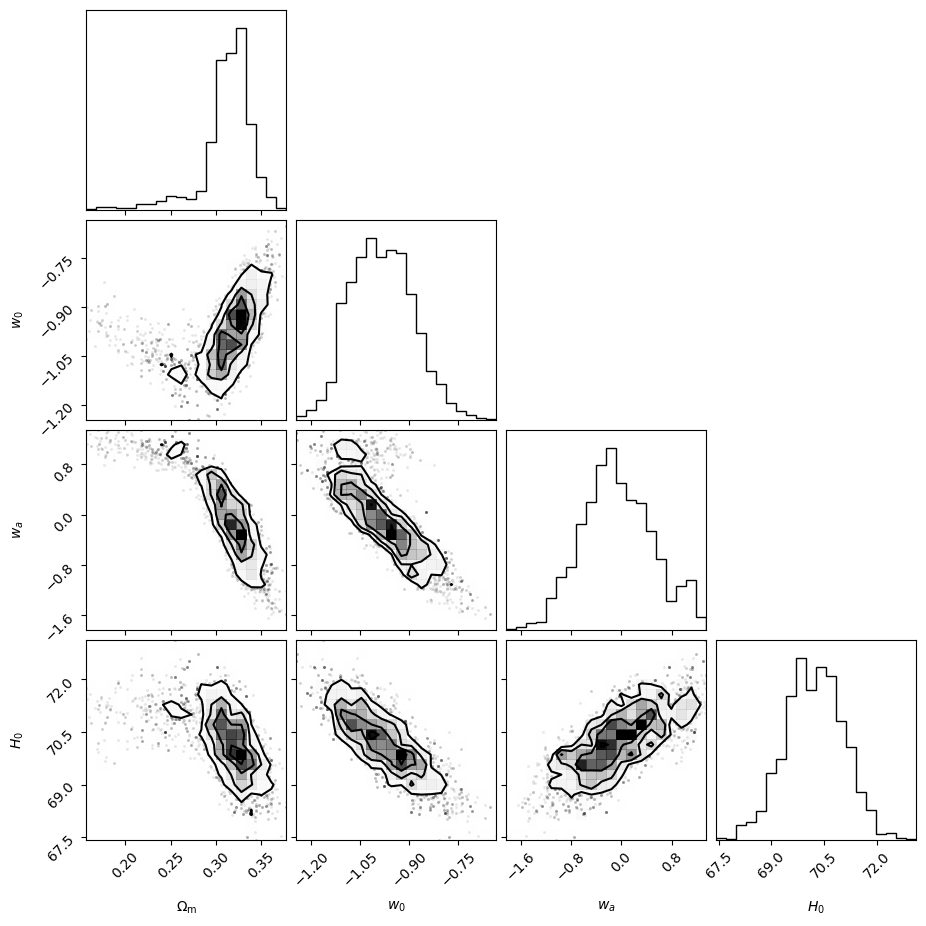

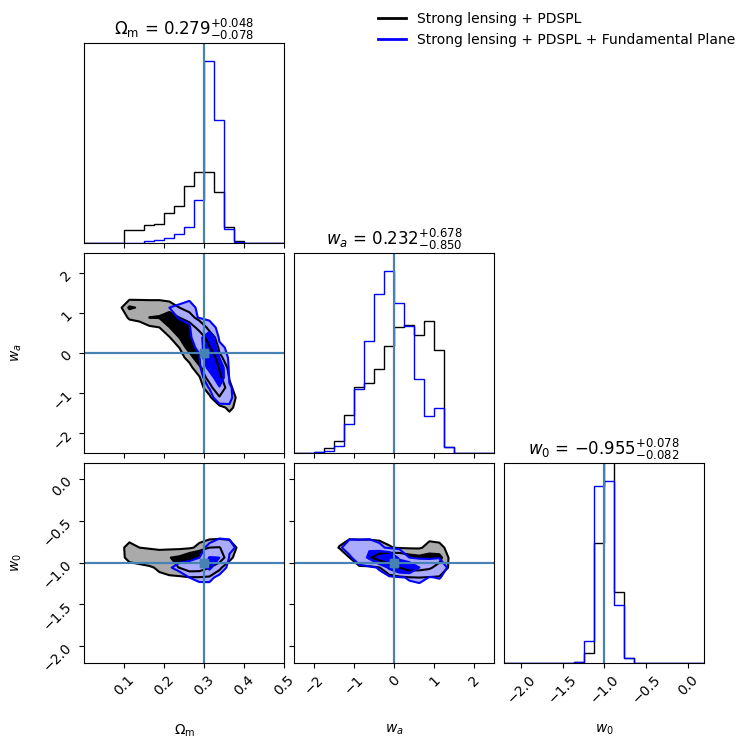

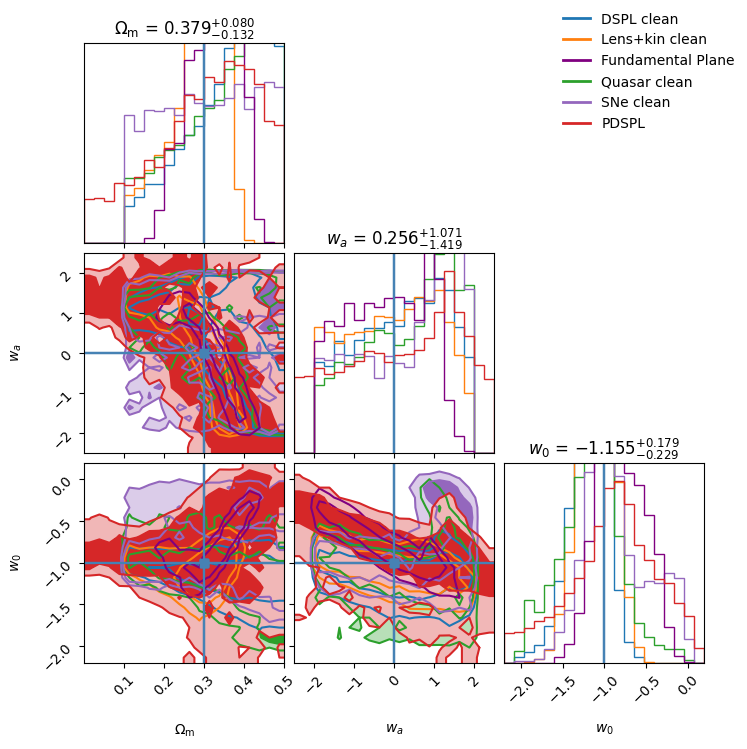

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


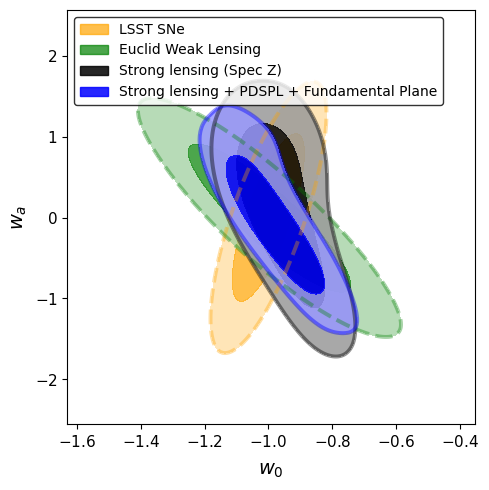

In [1]:
import os
from pathlib import Path

import arviz as az
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
import emcee
from scipy.stats import gaussian_kde

# -------------------------------
# Paths and reproducibility
# -------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

workdir = Path.cwd()

RESULT_DIR = Path(os.environ.get('SLCOSMO_RESULT_DIR', '/mnt/lustre/tianli/LensedUniverse_result'))
FIG_DIR = Path('result')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def first_existing(candidates, label):
    for p in candidates:
        if p.exists():
            return p
    cand_msg = '\n'.join([f'  - {c}' for c in candidates])
    raise FileNotFoundError(f'Cannot find {label}. Checked:\n{cand_msg}')


# -------------------------------
# Input files
# -------------------------------
joint_clean_path = first_existing(
    [
        RESULT_DIR / 'joint_clean.nc',
        workdir / 'result' / 'smoke_nc' / 'joint_clean.nc',
    ],
    'joint_clean.nc',
)

probe_paths = {
    'DSPL clean': first_existing([RESULT_DIR / 'dspl_clean.nc'], 'dspl_clean.nc'),
    'Lens+kin clean': first_existing([RESULT_DIR / 'lens_kin_clean.nc'], 'lens_kin_clean.nc'),
    'Quasar clean': first_existing([RESULT_DIR / 'quasar_clean.nc'], 'quasar_clean.nc'),
    'SNe clean': first_existing([RESULT_DIR / 'sne_clean.nc'], 'sne_clean.nc'),
}

pdspl_h5_path = workdir / 'data' / 'lsst_y10_dissim_leq_0.033.h5'
if not pdspl_h5_path.exists():
    raise FileNotFoundError(f'Cannot find PDSPL chain: {pdspl_h5_path}')

simple_gauss_path = workdir / 'data' / 'Simple_Gauss_likelihood_S0.033_tE0p01_106_20260513-073722P1of12_BGDFixTrue.csv'
if not simple_gauss_path.exists():
    raise FileNotFoundError(f'Cannot find Fundamental Plane CSV: {simple_gauss_path}')


# -------------------------------
# Helpers
# -------------------------------
def flatten_var(idata, var_name):
    if var_name not in idata.posterior:
        raise KeyError(f'Variable {var_name} not found in posterior.')
    arr = np.asarray(idata.posterior[var_name]).reshape(-1)
    return arr


def extract_matrix_from_idata(idata, vars_in_order):
    cols = [flatten_var(idata, v) for v in vars_in_order]
    mat = np.column_stack(cols)
    mask = np.isfinite(mat).all(axis=1)
    mat = mat[mask]
    if mat.shape[0] == 0:
        raise RuntimeError(f'No finite samples left for vars={vars_in_order}')
    return mat


def downsample_rows(x, n_max=50000, random_state=None):
    if x.shape[0] <= n_max:
        return x
    rr = np.random.default_rng(random_state)
    idx = rr.choice(x.shape[0], size=n_max, replace=False)
    return x[idx]


# -------------------------------
# Load posteriors
# -------------------------------
idata_joint_clean = az.from_netcdf(joint_clean_path)

# Euclid clean cosmology samples: Omegam, w0, wa, h0
joint_cosmo_vars = ['Omegam', 'w0', 'wa', 'h0']
joint_cosmo = extract_matrix_from_idata(idata_joint_clean, joint_cosmo_vars)
joint_cosmo = downsample_rows(joint_cosmo, n_max=120000, random_state=SEED)

# PDSPL posterior from emcee backend.
backend = emcee.backends.HDFBackend(str(pdspl_h5_path), read_only=True)
raw = backend.get_chain(flat=True, discard=400, thin=10)
if raw.shape[1] < 7:
    raise RuntimeError(f'Expected >=7 columns in PDSPL chain, got shape={raw.shape}')

columns = [
    r'$\Omega_{\rm m}$',
    r'$w_0$',
    r'$w_{\rm a}$',
    r'$\overline{\lambda}_{\rm int}$',
    r'$\sigma({\lambda}_{\rm int})$',
    r'$\overline{\gamma}_{\rm pl}$',
    r'$\sigma({\gamma}_{\rm pl})$',
]
df_pdspl = pd.DataFrame(raw[:, :7], columns=columns)

pdspl_cosmo = df_pdspl[[r'$\Omega_{\rm m}$', r'$w_0$', r'$w_{\rm a}$']].to_numpy()
pdspl_lambda = df_pdspl[r'$\overline{\lambda}_{\rm int}$'].to_numpy()

mask_pdspl = np.isfinite(pdspl_cosmo).all(axis=1) & np.isfinite(pdspl_lambda)
pdspl_cosmo = pdspl_cosmo[mask_pdspl]
pdspl_lambda = pdspl_lambda[mask_pdspl]

pdspl_pack = np.column_stack([pdspl_cosmo, pdspl_lambda])
pdspl_pack = downsample_rows(pdspl_pack, n_max=120000, random_state=SEED)
pdspl_cosmo = pdspl_pack[:, :3]
pdspl_lambda = pdspl_pack[:, 3]
# Synthetic H0 posterior for PDSPL importance: uniform in [60, 80].
pdspl_h0 = rng.uniform(60.0, 80.0, size=pdspl_cosmo.shape[0])

# Plot-alignment shift for PDSPL chain center (for visualization only).
target_center = np.array([0.32, -1.0, 0.0], dtype=float)  # [Omegam, w0, wa]
center_before = np.mean(pdspl_cosmo, axis=0)
shift_vec = target_center - center_before
pdspl_cosmo = pdspl_cosmo + shift_vec
center_after = np.mean(pdspl_cosmo, axis=0)

# Fundamental Plane posterior from CSV.
df_simple_gauss = pd.read_csv(simple_gauss_path)
required_simple_cols = ['OM', 'w', 'wa']
missing_simple_cols = [col for col in required_simple_cols if col not in df_simple_gauss.columns]
if missing_simple_cols:
    raise RuntimeError(f'Fundamental Plane CSV missing columns: {missing_simple_cols}')
simple_gauss_cosmo = df_simple_gauss[required_simple_cols].to_numpy(dtype=float)
mask_simple = np.isfinite(simple_gauss_cosmo).all(axis=1)
simple_gauss_cosmo = simple_gauss_cosmo[mask_simple]
simple_gauss_cosmo = downsample_rows(simple_gauss_cosmo, n_max=120000, random_state=SEED)


# -------------------------------
# Importance sampling (Euclid clean x PDSPL)
# -------------------------------
# Base weight from KDE in (Omegam,w0,wa), plus optional H0 KDE term when available.
kde = gaussian_kde(pdspl_cosmo.T)
logw = kde.logpdf(joint_cosmo[:, :3].T)

if pdspl_h0 is not None and pdspl_h0.size > 10:
    kde_h0 = gaussian_kde(pdspl_h0.reshape(1, -1))
    logw += kde_h0.logpdf(joint_cosmo[:, 3].reshape(1, -1))
else:
    pass
logw = logw - np.max(logw)
weights = np.exp(logw)
weights /= np.sum(weights)

ess = 1.0 / np.sum(weights**2)
ess_frac = ess / weights.size

def weighted_quantile(x, w, q):
    order = np.argsort(x)
    x_sorted = x[order]
    w_sorted = w[order]
    cdf = np.cumsum(w_sorted)
    cdf /= cdf[-1]
    return np.interp(q, cdf, x_sorted)


def summarize_unweighted(x):
    q16, q50, q84 = np.quantile(x, [0.16, 0.5, 0.84])
    return {
        'mean': float(np.mean(x)),
        'std': float(np.std(x, ddof=1)),
        'q16': float(q16),
        'q50': float(q50),
        'q84': float(q84),
    }


def summarize_weighted(x, w):
    mu = float(np.sum(w * x))
    var = float(np.sum(w * (x - mu) ** 2))
    return {
        'mean': mu,
        'std': float(np.sqrt(max(var, 0.0))),
        'q16': float(weighted_quantile(x, w, 0.16)),
        'q50': float(weighted_quantile(x, w, 0.50)),
        'q84': float(weighted_quantile(x, w, 0.84)),
    }


def weighted_cov_2d(x2d, w):
    mu = np.sum(w[:, None] * x2d, axis=0)
    xc = x2d - mu
    denom = max(1.0 - np.sum(w ** 2), 1e-12)
    cov = (xc * w[:, None]).T @ xc / denom
    return cov


cov_before = np.cov(joint_cosmo[:, [1, 2]].T, ddof=1)
cov_after = weighted_cov_2d(joint_cosmo[:, [1, 2]], weights)

det_before = float(np.linalg.det(cov_before))
det_after = float(np.linalg.det(cov_after))
fom_before = np.inf if det_before <= 0 else 1.0 / np.sqrt(det_before)
fom_after = np.inf if det_after <= 0 else 1.0 / np.sqrt(det_after)

print('\nw0-wa FoM')
print(f"Before importance sampling: {fom_before:.4f}")
if np.isfinite(fom_before) and fom_before > 0 and np.isfinite(fom_after):
    print(f"After PDSPL importance sampling: {fom_after:.4f} (ratio={fom_after / fom_before:.3f})")
else:
    print(f"After PDSPL importance sampling: {fom_after:.4f}")

n_is = min(100000, joint_cosmo.shape[0])
idx_is = rng.choice(joint_cosmo.shape[0], size=n_is, replace=True, p=weights)
joint_cosmo_is = joint_cosmo[idx_is]

n_plot = min(80000, joint_cosmo.shape[0], pdspl_cosmo.shape[0], joint_cosmo_is.shape[0])
idx_joint = rng.choice(joint_cosmo.shape[0], size=n_plot, replace=False)
idx_pdspl = rng.choice(pdspl_cosmo.shape[0], size=n_plot, replace=False)
idx_is_plot = rng.choice(joint_cosmo_is.shape[0], size=n_plot, replace=False)

joint_plot = joint_cosmo[idx_joint]
pdspl_plot = pdspl_cosmo[idx_pdspl]
joint_is_plot = joint_cosmo_is[idx_is_plot]


# -------------------------------
# Importance sampling (joint strong-lensing posterior x Fundamental Plane CSV)
# -------------------------------
kde_simple = gaussian_kde(simple_gauss_cosmo.T)
logw_simple = kde_simple.logpdf(joint_cosmo[:, :3].T)
logw_simple = logw_simple - np.max(logw_simple)
weights_simple = np.exp(logw_simple)
weights_simple /= np.sum(weights_simple)

ess_simple = 1.0 / np.sum(weights_simple**2)
ess_simple_frac = ess_simple / weights_simple.size

cov_simple = weighted_cov_2d(joint_cosmo[:, [1, 2]], weights_simple)
det_simple = float(np.linalg.det(cov_simple))
fom_simple = np.inf if det_simple <= 0 else 1.0 / np.sqrt(det_simple)
if np.isfinite(fom_before) and fom_before > 0 and np.isfinite(fom_simple):
    print(f"After Fundamental Plane importance sampling: {fom_simple:.4f} (ratio={fom_simple / fom_before:.3f})")
else:
    print(f"After Fundamental Plane importance sampling: {fom_simple:.4f}")

idx_simple_is = rng.choice(joint_cosmo.shape[0], size=n_is, replace=True, p=weights_simple)
joint_cosmo_simple_is = joint_cosmo[idx_simple_is]
n_plot_simple = min(80000, joint_cosmo.shape[0], simple_gauss_cosmo.shape[0], joint_cosmo_simple_is.shape[0])
idx_simple_plot = rng.choice(joint_cosmo_simple_is.shape[0], size=n_plot_simple, replace=False)
joint_simple_plot = joint_cosmo_simple_is[idx_simple_plot]

# Combined importance sampling: joint strong-lensing posterior x PDSPL x Fundamental Plane.
logw_both = logw + logw_simple
logw_both = logw_both - np.max(logw_both)
weights_both = np.exp(logw_both)
weights_both /= np.sum(weights_both)

ess_both = 1.0 / np.sum(weights_both**2)
ess_both_frac = ess_both / weights_both.size

cov_both = weighted_cov_2d(joint_cosmo[:, [1, 2]], weights_both)
det_both = float(np.linalg.det(cov_both))
fom_both = np.inf if det_both <= 0 else 1.0 / np.sqrt(det_both)
if np.isfinite(fom_before) and fom_before > 0 and np.isfinite(fom_both):
    print(f"After PDSPL + Fundamental Plane importance sampling: {fom_both:.4f} (ratio={fom_both / fom_before:.3f})")
else:
    print(f"After PDSPL + Fundamental Plane importance sampling: {fom_both:.4f}")

idx_both_is = rng.choice(joint_cosmo.shape[0], size=n_is, replace=True, p=weights_both)
joint_cosmo_both_is = joint_cosmo[idx_both_is]
n_plot_both = min(80000, joint_cosmo.shape[0], joint_cosmo_is.shape[0], joint_cosmo_both_is.shape[0])
idx_both_plot = rng.choice(joint_cosmo_both_is.shape[0], size=n_plot_both, replace=False)
joint_both_plot = joint_cosmo_both_is[idx_both_plot]


# -------------------------------
# Figure 1: Total posterior (joint strong lensing x PDSPL x Fundamental Plane) in Omegam-w0-wa-H0.
# Use corner defaults, only set labels.
# -------------------------------
labels_total = [r'$\Omega_{\rm m}$', r'$w_0$', r'$w_a$', r'$H_0$']

fig1 = corner.corner(
    joint_both_plot[:, :4],
    labels=labels_total,
)

out1_png = FIG_DIR / 'total_posterior_jointpluspdspl_fp_omegam_w0_wa_h0.png'
out1_pdf = FIG_DIR / 'total_posterior_jointpluspdspl_fp_omegam_w0_wa_h0.pdf'
fig1.savefig(out1_png, dpi=220, bbox_inches='tight')
fig1.savefig(out1_pdf, bbox_inches='tight')
plt.show()


# -------------------------------
# Figure 2: overlay of the PDSPL-only and PDSPL+Fundamental-Plane posteriors.
# Only compare cosmology dimensions: Omegam, wa, w0.
# -------------------------------
labels_5 = [r'$\Omega_{\mathrm{m}}$', r'$w_a$', r'$w_0$']
truths_5 = [0.3, 0.0, -1.0]
ranges_5 = ((0.0, 0.5), (-2.5, 2.5), (-2.2, 0.2))

joint_pdspl_overlay = joint_is_plot[:, [0, 2, 1]]
joint_pdspl_fp_overlay = joint_both_plot[:, [0, 2, 1]]

colors2 = {
    'Strong lensing + PDSPL': 'black',
    'Strong lensing + PDSPL + Fundamental Plane': 'blue',
}

fig2 = corner.corner(
    joint_pdspl_overlay,
    labels=labels_5,
    color=colors2['Strong lensing + PDSPL'],
    show_titles=True,
    title_fmt='.3f',
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

corner.corner(
    joint_pdspl_fp_overlay,
    fig=fig2,
    color=colors2['Strong lensing + PDSPL + Fundamental Plane'],
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

handles2 = [plt.Line2D([], [], color=colors2[name], lw=2) for name in colors2]
labels2 = list(colors2)
fig2.legend(handles2, labels2, loc='upper right', frameon=False)

out2_png = FIG_DIR / 'overlay_joint_pdspl_vs_joint_pdspl_fp_omegam_wa_w0.png'
out2_pdf = FIG_DIR / 'overlay_joint_pdspl_vs_joint_pdspl_fp_omegam_wa_w0.pdf'
fig2.savefig(out2_png, dpi=220, bbox_inches='tight')
fig2.savefig(out2_pdf, bbox_inches='tight')
plt.show()


# -------------------------------
# Figure 3: different-probe posterior overlay.
# Only compare cosmology dimensions: Omegam, wa, w0.
# -------------------------------
probe_mats = {}
for probe_name, probe_path in probe_paths.items():
    idata_probe = az.from_netcdf(probe_path)
    needed = ['Omegam', 'wa', 'w0']
    miss = [v for v in needed if v not in idata_probe.posterior]
    if miss:
        raise RuntimeError(f'{probe_name} missing vars: {miss}')
    mat = extract_matrix_from_idata(idata_probe, needed)
    probe_mats[probe_name] = downsample_rows(mat, n_max=70000, random_state=SEED)

pdspl_overlay = pdspl_cosmo[:, [0, 2, 1]]  # stored as Omegam, w0, wa; plot as Omegam, wa, w0
pdspl_overlay = downsample_rows(pdspl_overlay, n_max=70000, random_state=SEED)
fundamental_plane_overlay = simple_gauss_cosmo[:, [0, 2, 1]]  # stored as OM, w, wa; plot as Omegam, wa, w0
fundamental_plane_overlay = downsample_rows(fundamental_plane_overlay, n_max=70000, random_state=SEED)

probe_colors = {
    'DSPL clean': 'C0',
    'Lens+kin clean': 'C1',
    'Fundamental Plane': 'purple',
    'Quasar clean': 'C2',
    'SNe clean': 'C4',
    'PDSPL': 'C3',
}

fig_probe = corner.corner(
    probe_mats['DSPL clean'],
    labels=labels_5,
    color=probe_colors['DSPL clean'],
    show_titles=True,
    title_fmt='.3f',
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

for name in ['Lens+kin clean', 'Quasar clean', 'SNe clean']:
    corner.corner(
        probe_mats[name],
        fig=fig_probe,
        color=probe_colors[name],
        truths=truths_5,
        range=ranges_5,
        smooth=0.2,
        plot_datapoints=False,
        fill_contours=True,
        hist_kwargs=dict(density=True),
        levels=[0.68, 0.95],
    )

corner.corner(
    fundamental_plane_overlay,
    fig=fig_probe,
    color=probe_colors['Fundamental Plane'],
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

corner.corner(
    pdspl_overlay,
    fig=fig_probe,
    color=probe_colors['PDSPL'],
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)

probe_names = ['DSPL clean', 'Lens+kin clean', 'Fundamental Plane', 'Quasar clean', 'SNe clean', 'PDSPL']
handles_probe = [plt.Line2D([], [], color=probe_colors[name], lw=2) for name in probe_names]
fig_probe.legend(handles_probe, probe_names, loc='upper right', frameon=False)

out_probe_png = FIG_DIR / 'six_probe_posteriors_overlay_omegam_wa_w0.png'
out_probe_pdf = FIG_DIR / 'six_probe_posteriors_overlay_omegam_wa_w0.pdf'
fig_probe.savefig(out_probe_png, dpi=220, bbox_inches='tight')
fig_probe.savefig(out_probe_pdf, bbox_inches='tight')
plt.show()


# -------------------------------
# Figure 4: LSST SNe, Euclid WL, Spec Z, and PDSPL + FP Gaussian likelihood (w0-wa)
# -------------------------------
out3_png = None
out3_pdf = None
try:
    from getdist import plots, MCSamples

    other_forecast_env = os.environ.get('OTHER_FORECAST_DIR')
    if other_forecast_env:
        other_forecast_dir = Path(other_forecast_env)
    else:
        forecast_candidates = [
            Path('/users/tianli/slcosmo/other_forecast'),
            Path('/users/tianli/SLCOSMO/other_forecast'),
            workdir.parent / 'slcosmo' / 'other_forecast',
            workdir.parent / 'SLCOSMO' / 'other_forecast',
            workdir / 'data' / 'other_forecast',
            workdir.parent / 'Cosmology' / 'data',
        ]
        other_forecast_dir = next((pp for pp in forecast_candidates if pp.exists()), forecast_candidates[-1])
    sne_path = first_existing(
        [
            other_forecast_dir / 'Y10_SN.txt',
            workdir / 'data' / 'other_forecast' / 'Y10_SN.txt',
            workdir.parent / 'Cosmology' / 'data' / 'Y10_SN.txt',
            workdir.parent / 'Cosmology' / 'old' / 'Y10_SN.txt',
        ],
        'Y10_SN.txt',
    )

    wl_path = first_existing(
        [
            other_forecast_dir / 'EuclidISTF_WL_w0wa_flat_pessimistic.txt',
            workdir / 'data' / 'other_forecast' / 'EuclidISTF_WL_w0wa_flat_pessimistic.txt',
            workdir.parent / 'Cosmology' / 'data' / 'EuclidISTF_WL_w0wa_flat_pessimistic.txt',
        ],
        'EuclidISTF_WL_w0wa_flat_pessimistic.txt',
    )

    posterior_supernovae = pd.DataFrame(
        np.genfromtxt(sne_path),
        columns=['Omega_m', 'sigma_8', 'n_s', 'w_0', 'w_a', 'Omega_b', 'H_0'],
    )
    samples_supernovae = posterior_supernovae[['w_0', 'w_a']].to_numpy()

    param_names_all = [
        'Omegam', 'Omegab', 'w0', 'wa', 'h', 'ns', 'sigma8', 'aIA', 'etaIA', 'betaIA',
        'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10',
    ]
    fisher_matrix = np.genfromtxt(wl_path)
    covariance_matrix = np.linalg.inv(fisher_matrix)
    idx_w0 = param_names_all.index('w0')
    idx_wa = param_names_all.index('wa')
    cov_sub = covariance_matrix[np.ix_([idx_w0, idx_wa], [idx_w0, idx_wa])]
    samples_euclid_wl = rng.multivariate_normal([-1.0, 0.0], cov_sub, size=10000)

    samples_specz_w0wa = np.asarray(joint_cosmo[:, [1, 2]], dtype=float)
    samples_pdspl_fp_w0wa = np.asarray(joint_both_plot[:, [1, 2]], dtype=float)

    names = ['w0', 'wa']
    labels = [r'w_0', r'w_a']

    smooth_2d_compare = 0.8
    mc_sne = MCSamples(samples=samples_supernovae, names=names, labels=labels, settings={'smooth_scale_2D': smooth_2d_compare})
    mc_euclid = MCSamples(samples=samples_euclid_wl, names=names, labels=labels, settings={'smooth_scale_2D': smooth_2d_compare})
    mc_specz = MCSamples(samples=samples_specz_w0wa, names=names, labels=labels, settings={'smooth_scale_2D': smooth_2d_compare})
    mc_pdspl_fp = MCSamples(samples=samples_pdspl_fp_w0wa, names=names, labels=labels, settings={'smooth_scale_2D': smooth_2d_compare})

    g = plots.get_subplot_plotter(subplot_size=5)
    if hasattr(g.settings, 'smooth_scale_2D'):
        g.settings.smooth_scale_2D = smooth_2d_compare
    g.plot_2d(
        [mc_sne, mc_euclid, mc_specz, mc_pdspl_fp],
        param_pair=('w0', 'wa'),
        filled=[True, True, True, True],
        line_args=[
            {'ls': '--', 'alpha': 0.7, 'lw': 2},
            {'ls': '--', 'alpha': 0.7, 'lw': 2},
            {'ls': '-', 'lw': 2},
            {'ls': '-', 'lw': 2},
        ],
        colors=['orange', 'green', 'black', 'blue'],
    )

    g.add_legend(
        [
            'LSST SNe',
            'Euclid Weak Lensing',
            'Strong lensing (Spec Z)',
            'Strong lensing + PDSPL + Fundamental Plane',
        ],
        frameon=True,
        framealpha=0.8,
        edgecolor='black',
        facecolor='white',
        fontsize=10,
        legend_loc='upper left',
    )

    out3_pdf = FIG_DIR / 'jointcompare_forecasts_specz_vs_pdspl_fp_simplegauss_s0033.pdf'
    out3_png = FIG_DIR / 'jointcompare_forecasts_specz_vs_pdspl_fp_simplegauss_s0033.png'
    g.export(str(out3_pdf))
    g.fig.savefig(out3_png, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(g.fig)

except Exception as err:
    print(f'[WARN] Skip w0-wa comparison plot: {err}')



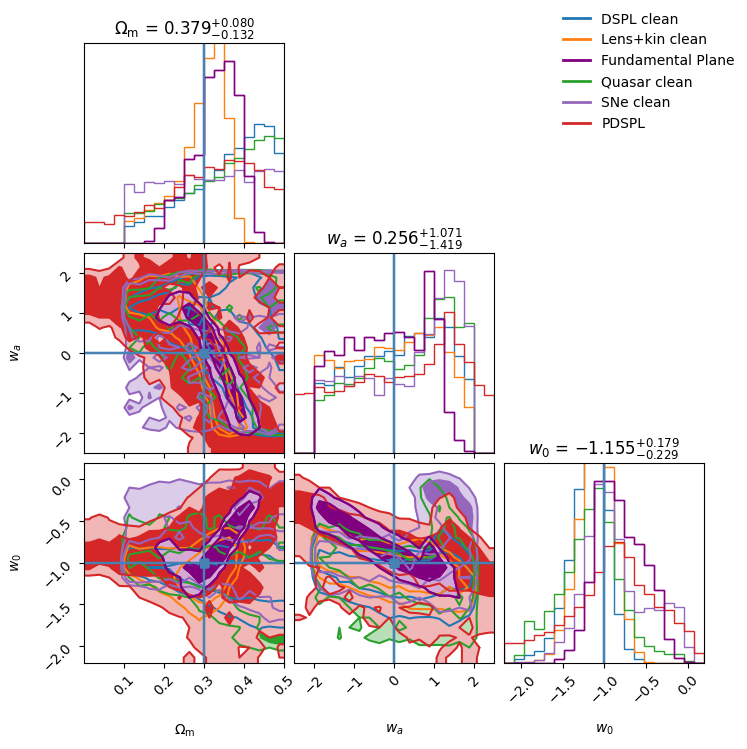

In [2]:
corner.corner(
    fundamental_plane_overlay,
    fig=fig_probe,
    color=probe_colors['Fundamental Plane'],
    truths=truths_5,
    range=ranges_5,
    smooth=0.2,
    plot_datapoints=False,
    fill_contours=True,
    hist_kwargs=dict(density=True),
    levels=[0.68, 0.95],
)